In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#warnings suppress unnecessary warnings 
warnings.filterwarnings('ignore')
#plots appear inside the noteboook
%matplotlib inline

#makes seaborn plots look clean and proffessional
sns.set_style('whitegrid')
sns.set_palette('husl')


In [64]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')


In [3]:
train.head(5)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
test.head(5)

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [6]:
# VERY IMPORTANT — this is exactly how our final file must look
# Two columns: Index (from test.csv) and demand (our predictions)

print("=== SAMPLE SUBMISSION ===")
print(sample_sub)

=== SAMPLE SUBMISSION ===
   Index    demand
0      0  0.090768
1      1  0.089885
2      2  0.007037
3      3  0.079087
4      4  0.054636


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          41778 non-null  int64  
 1   geohash        41778 non-null  object 
 2   day            41778 non-null  int64  
 3   timestamp      41778 non-null  object 
 4   RoadType       41454 non-null  object 
 5   NumberofLanes  41778 non-null  int64  
 6   LargeVehicles  41778 non-null  object 
 7   Landmarks      41778 non-null  object 
 8   Temperature    40429 non-null  float64
 9   Weather        41347 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 3.2+ MB


In [9]:
train.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [10]:
test.describe()

,Index,day,NumberofLanes,Temperature
count,41778.00000,41778.0,41778.000000,40429.000000
mean,20888.50000,49.0,2.068984,16.457339
std,12060.41411,0.0,0.988519,7.351067
min,0.00000,49.0,1.000000,-21.314645
25%,10444.25000,49.0,1.000000,11.527029
50%,20888.50000,49.0,2.000000,16.471232
75%,31332.75000,49.0,3.000000,21.365883
max,41777.00000,49.0,5.000000,45.230408


In [11]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [12]:
test.isnull().sum()


Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [65]:
#------------------------MISSING VALUE ANALYSIS---------------------
missing_train =pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})

print(missing_train[missing_train['Missing Count'] > 0])

print("\n=== MISSING VALUES IN TEST ===")
missing_test = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_test[missing_test['Missing Count'] > 0])


#this part of the code is used to calculate the missing count and as well as its percentage so that we can calculate the severity as well

             Missing Count  Missing %
RoadType               600       0.78
Temperature           2495       3.23
Weather                797       1.03

=== MISSING VALUES IN TEST ===
             Missing Count  Missing %
RoadType               324       0.78
Temperature           1349       3.23
Weather                431       1.03


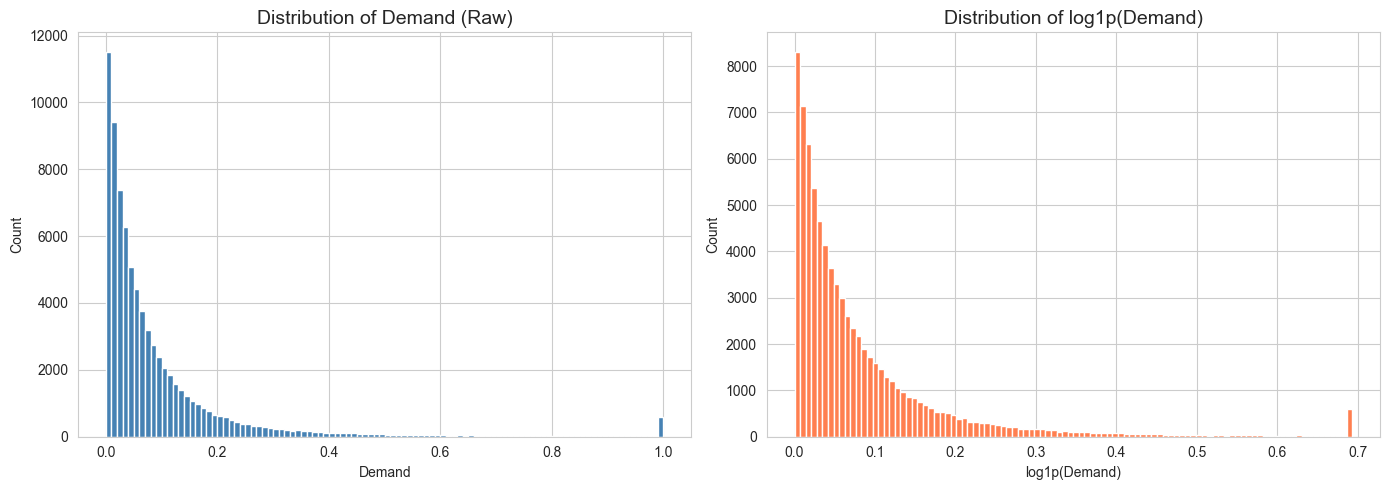


== DEMAND STATISTICS ==
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [66]:
#---------------------------TARGET VARIABLE DISTRIBUTION -------------------------------------
# The target is demand — a float between 0 and 1
# We plot its distribution to understand skewness
# Right-skewed → most locations have LOW demand, a few have VERY HIGH demand

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw distribution
axes[0].hist(train['demand'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Demand (Raw)', fontsize=14)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

# Right plot: log distribution — helps us see the shape better
axes[1].hist(np.log1p(train['demand']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(Demand)', fontsize=14)
axes[1].set_xlabel('log1p(Demand)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n== DEMAND STATISTICS ==")
print(train['demand'].describe())

In [16]:
#-------------------------- Unique Values in Each Column--------------------------------------



# Understanding cardinality (number of unique values) for categorical columns
# This tells us which columns need label encoding vs one-hot encoding

categorical_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

print("=== UNIQUE VALUE COUNTS ===")
for col in categorical_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts(dropna=False).head(6))




    

=== UNIQUE VALUE COUNTS ===

geohash: 1249 unique values
geohash
qp03wd    105
qp03wf    105
qp09t0    105
qp03w9    105
qp03x3    105
qp03wc    105
Name: count, dtype: int64

RoadType: 3 unique values
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

LargeVehicles: 2 unique values
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

Landmarks: 2 unique values
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

Weather: 4 unique values
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64


In [24]:
# geohasH has 1249 unique values------------->labelencoding
# roadtype has 3 unique values-------------->ONE HOT ENCODING
# largeVehciles has 2 unique values---------->ONE HOT ENCODING
# LandMarks has 2 unique values-------------->BINARY OR LABEL ENCODING
# weather has 4 unique values---------------> ONE HOT ENCODING

In [67]:
#------------------------------- Day & Timestamp Analysis-------------------------


print("===DAY DISTRIBUTION===")
print("Train Days:", sorted(train['day'].unique())) #find all distinct days in train dataset
print("Test Days :", sorted(test['day'].unique()))  #find all distinct days in test dataset
print()
print(train['day'].value_counts())   #count value of train dataset

print("===time sample===")
print("Total unique timestamps:", train['timestamp'].nunique())  #count unique timestamp values



===DAY DISTRIBUTION===
Train Days: [np.int64(48), np.int64(49)]
Test Days : [np.int64(49)]

day
48    69427
49     7872
Name: count, dtype: int64
===time sample===
Total unique timestamps: 96


In [68]:
print("Sample timestamps:", sorted(train['timestamp'].unique())[:10])   #shows first 10 of sorted
print("... (96 total = 24 hours × 4 slots per hour = 15-min intervals)") # HERE 96 TIMESTAMPS ARE UIQUE 24 HOURS* 4 INTERVALS/HOURS

Sample timestamps: ['0:0', '0:15', '0:30', '0:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15']
... (96 total = 24 hours × 4 slots per hour = 15-min intervals)


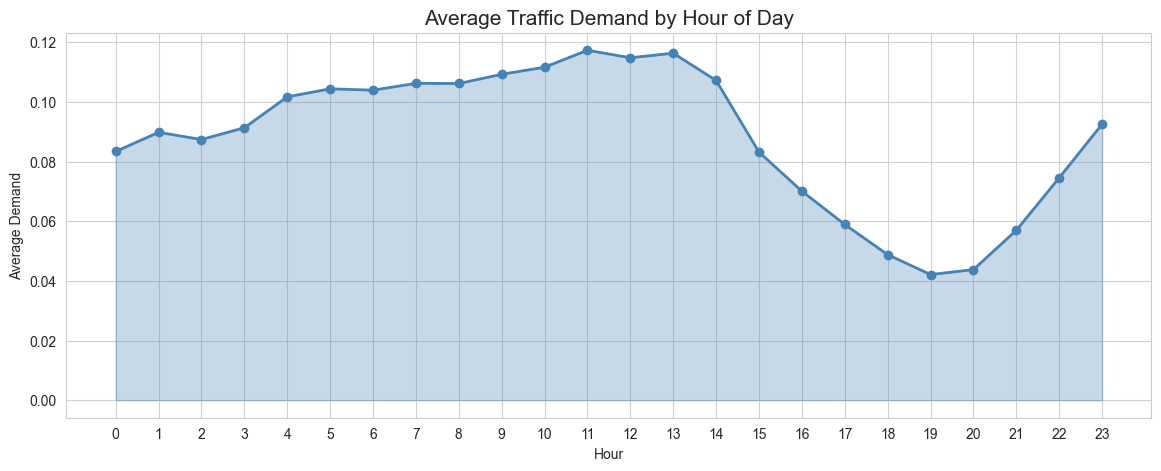

In [69]:
###---------------------Demand by Hour of Day-----------------------


# Extract hour from timestamp to see rush hour patterns
# This is one of the MOST IMPORTANT features

# Parse hour from "H:MM" format
train['hour'] = train['timestamp'].apply(lambda x: int(x.split(':')[0]))   #IT EXTRACTS THE HOUR 

# Average demand per hour
hourly_demand = train.groupby('hour')['demand'].mean().reset_index()   #CALC AVG DEMAND PER HOUR


# PLOT THE FIGURE
plt.figure(figsize=(14, 5))   
plt.plot(hourly_demand['hour'], hourly_demand['demand'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(hourly_demand['hour'], hourly_demand['demand'], alpha=0.3, color='steelblue')
plt.title('Average Traffic Demand by Hour of Day', fontsize=15)
plt.xlabel('Hour')
plt.ylabel('Average Demand')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.9)
plt.show()

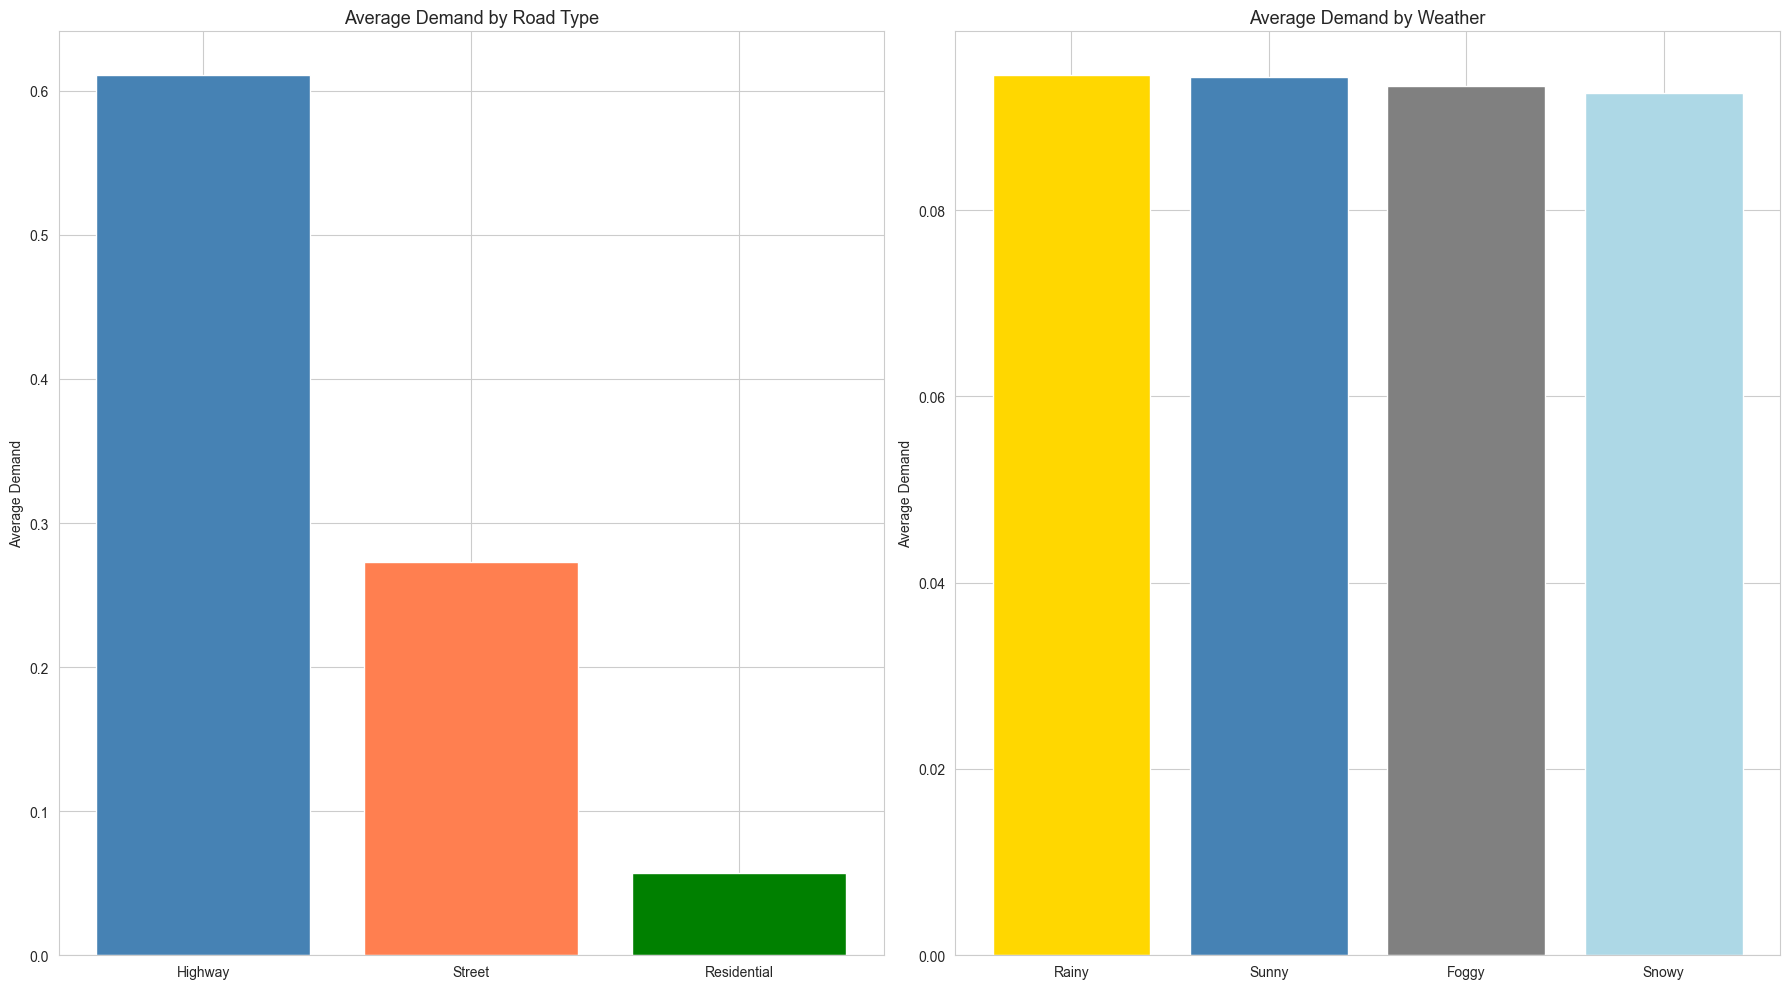

In [27]:
##########------------------Demand by Road Type & Weather-----------------


fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Demand by Road Type
road_demand = train.groupby('RoadType')['demand'].mean().sort_values(ascending=False)
axes[0].bar(road_demand.index, road_demand.values, color=['steelblue','coral','green'])
axes[0].set_title('Average Demand by Road Type', fontsize=13)
axes[0].set_ylabel('Average Demand')

# Demand by Weather
weather_demand = train.groupby('Weather')['demand'].mean().sort_values(ascending=False)
axes[1].bar(weather_demand.index, weather_demand.values, 
            color=['gold','steelblue','gray','lightblue'])
axes[1].set_title('Average Demand by Weather', fontsize=13)
axes[1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()



In [28]:
#########--------------GEOHASH COVERAGE------------



# Geohash is a location code — like a postal code for GPS coordinates
# Understanding overlap between train and test geohashes is critical

train_geo = set(train['geohash'].unique())
test_geo  = set(test['geohash'].unique())

print(F"Unique geohashes in Train : {len(train_geo)}")
print(f"Unique geohashes in Test  : {len(test_geo)}")
print(f"Geohashes in BOTH         : {len(train_geo & test_geo)}")
print(f"In Test but NOT in Train  : {len(test_geo - train_geo)}")
print()
print(" Only 10 test geohashes are unseen — 99.2% overlap!")
print(" We can safely use geohash-level aggregations as features")

Unique geohashes in Train : 1249
Unique geohashes in Test  : 1190
Geohashes in BOTH         : 1180
In Test but NOT in Train  : 10

 Only 10 test geohashes are unseen — 99.2% overlap!
 We can safely use geohash-level aggregations as features


 Correlation between Day 48 and Day 49 demand: 0.7924
   (For same geohash + timestamp)

Test rows that HAVE a day48 lag: 37136 / 41778
This single feature alone will be incredibly powerful!


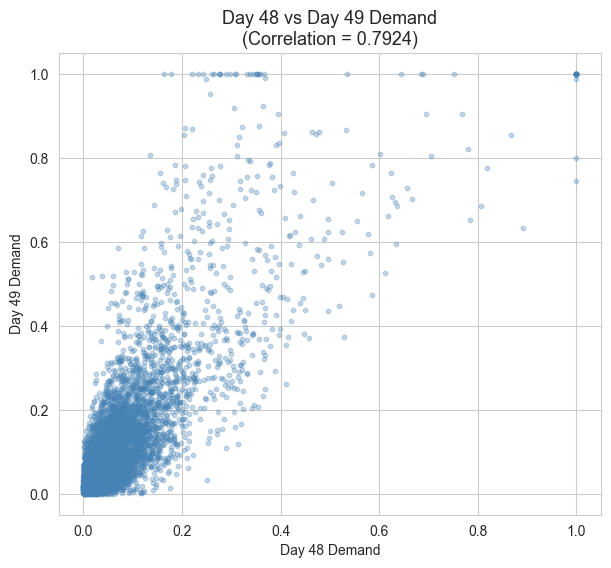

In [29]:

# Since train has day 48 and test is day 49,
# we can use day 48 demand as a "lag feature" to predict day 49 demand


day48 = train[train['day'] == 48][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_demand_day48'}
)
day49_train = train[train['day'] == 49][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_day49'}
)

# Merge day48 and day49 on same geohash+timestamp
overlap = day48.merge(day49_train, on=['geohash', 'timestamp'], how='inner')

# Calculate correlation
corr = overlap['lag_demand_day48'].corr(overlap['lag_day49'])
print(f" Correlation between Day 48 and Day 49 demand: {corr:.4f}")
print(f"   (For same geohash + timestamp)")
print()
print(f"Test rows that HAVE a day48 lag: {len(day48.merge(test, on=['geohash','timestamp'], how='inner'))} / {len(test)}")
print("This single feature alone will be incredibly powerful!")

# Visualize
plt.figure(figsize=(7,6))
plt.scatter(overlap['lag_demand_day48'], overlap['lag_day49'], 
            alpha=0.3, s=10, color='steelblue')
plt.xlabel('Day 48 Demand')
plt.ylabel('Day 49 Demand')
plt.title(f'Day 48 vs Day 49 Demand\n(Correlation = {corr:.4f})', fontsize=13)
plt.show()

In [70]:
#---------CONVERT THE STRING INTO NUMBER-------------
def parse_timestamp(df):
    # Split "8:15" into hour=8, minute=15
    df['hour']   = df['timestamp'].apply(lambda x: int(x.split(':')[0]))
    df['minute'] = df['timestamp'].apply(lambda x: int(x.split(':')[1]))
    
    # time_slot: converts to slot number 0–95 (96 slots in a day, every 15 min)
    # e.g. 8:15 → 8*4 + 1 = 33
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    
    return df

train = parse_timestamp(train)
test  = parse_timestamp(test)

print(" ::::Timestamp parsed!")
print(train[['timestamp','hour','minute','time_slot']].head(8))

 ::::Timestamp parsed!
  timestamp  hour  minute  time_slot
0       0:0     0       0          0
1       0:0     0       0          0
2       0:0     0       0          0
3       0:0     0       0          0
4       0:0     0       0          0
5       0:0     0       0          0
6       0:0     0       0          0
7       0:0     0       0          0


In [71]:
#--------CYCLICAL TIME ENCODING
#SIN/COS ENCODING WRAPS THE TIME IN CIRCLE......0 AND 23 AREE CLOSE BUT NUMERICALLY THEY ARE TOO FAR

train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)

train['time_slot_sin'] = np.sin(2 * np.pi * train['time_slot'] / 96)
train['time_slot_cos'] = np.cos(2 * np.pi * train['time_slot'] / 96)

test['hour_sin'] = np.sin(2 * np.pi * test['hour'] / 24)
test['hour_cos'] = np.cos(2 * np.pi * test['hour'] / 24)

test['time_slot_sin'] = np.sin(2 * np.pi * test['time_slot'] / 96)
test['time_slot_cos'] = np.cos(2 * np.pi * test['time_slot'] / 96)

print(" :::::Cyclical features created!")
print(train[['hour','hour_sin','hour_cos','time_slot_sin','time_slot_cos']].head(5))

 :::::Cyclical features created!
   hour  hour_sin  hour_cos  time_slot_sin  time_slot_cos
0     0       0.0       1.0            0.0            1.0
1     0       0.0       1.0            0.0            1.0
2     0       0.0       1.0            0.0            1.0
3     0       0.0       1.0            0.0            1.0
4     0       0.0       1.0            0.0            1.0


In [72]:
import sys
!{sys.executable} -m pip install pygeohash


 Geohash decoded to lat/lon!
  geohash  latitude  longitude
0  qp02z1 -5.484924  90.664673
1  qp02zt -5.462952  90.686646
2  qp08bj -5.462952  90.708618
3  qp08gt -5.462952  90.862427
4  qp02zq -5.457458  90.675659


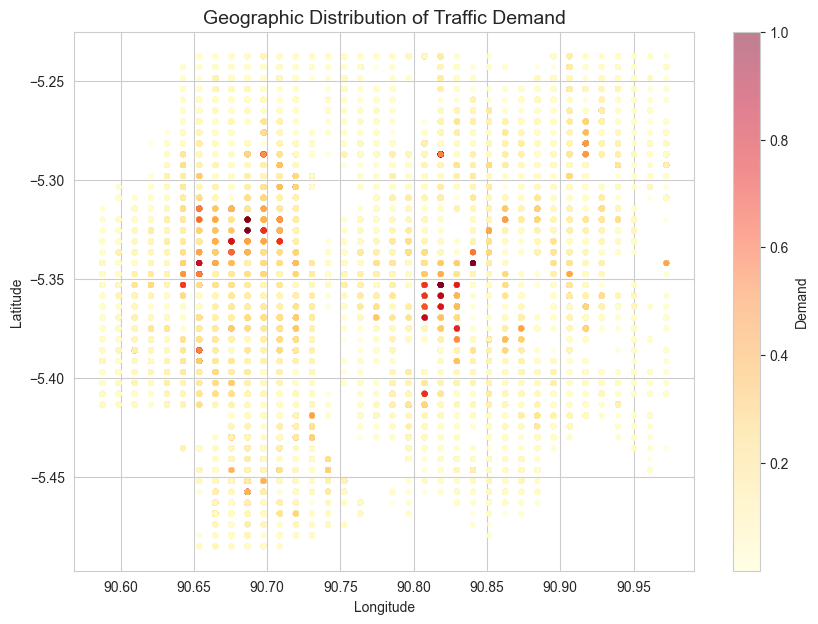

In [73]:

import pygeohash as geohash  # ← only this line changes

def decode_geohash(df):
    # decode() returns (latitude, longitude, lat_err, lon_err)
    # We only need lat and lon
    df['latitude']  = df['geohash'].apply(lambda x: geohash.decode(x)[0])
    df['longitude'] = df['geohash'].apply(lambda x: geohash.decode(x)[1])
    return df

train = decode_geohash(train)
test  = decode_geohash(test)

print(" Geohash decoded to lat/lon!")
print(train[['geohash','latitude','longitude']].head(5))

# Visualize the geographic spread
plt.figure(figsize=(10,7))
plt.scatter(train['longitude'], train['latitude'], 
            c=train['demand'], cmap='YlOrRd', 
            alpha=0.5, s=10)
plt.colorbar(label='Demand')
plt.title('Geographic Distribution of Traffic Demand', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [74]:
#-----ENCODE CATEGORICAL COLUMN

# Binary columns — simple map
# LargeVehicles: "Allowed" → 1, "Not Allowed" → 0
# Landmarks: "Yes" → 1, "No" → 0

train['LargeVehicles'] = train['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0})
test['LargeVehicles']  = test['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0})

train['Landmarks'] = train['Landmarks'].map({'Yes': 1, 'No': 0})
test['Landmarks']  = test['Landmarks'].map({'Yes': 1, 'No': 0})

# RoadType — label encode (Residential=0, Primary=1, etc.)
road_map = {v: i for i, v in enumerate(train['RoadType'].dropna().unique())}
print("RoadType mapping:", road_map)

train['RoadType'] = train['RoadType'].map(road_map)
test['RoadType']  = test['RoadType'].map(road_map)

# Weather — label encode
weather_map = {v: i for i, v in enumerate(train['Weather'].dropna().unique())}
print("Weather mapping:", weather_map)

train['Weather'] = train['Weather'].map(weather_map)
test['Weather']  = test['Weather'].map(weather_map)

print("\n  Categorical columns encoded!")
print(train[['LargeVehicles','Landmarks','RoadType','Weather']].head(5))

RoadType mapping: {'Residential': 0, 'Street': 1, 'Highway': 2}
Weather mapping: {'Sunny': 0, 'Rainy': 1, 'Foggy': 2, 'Snowy': 3}

  Categorical columns encoded!
   LargeVehicles  Landmarks  RoadType  Weather
0              0          0       NaN      NaN
1              1          1       0.0      0.0
2              0          0       0.0      0.0
3              0          0       0.0      1.0
4              0          0       0.0      1.0


In [75]:
#----------FILL MISSING VALUE
#TTHAT DEVELOPED DUE TO ENOCODING

# --- RoadType: fill with mode per geohash, else overall mode ---
road_mode_per_geo = train.groupby('geohash')['RoadType'].agg(
    lambda x: x.mode()[0] if x.notna().sum() > 0 else np.nan
)
overall_road_mode = train['RoadType'].mode()[0]

train['RoadType'] = train.apply(
    lambda row: road_mode_per_geo.get(row['geohash'], overall_road_mode) 
    if pd.isna(row['RoadType']) else row['RoadType'], axis=1
)
test['RoadType'] = test.apply(
    lambda row: road_mode_per_geo.get(row['geohash'], overall_road_mode) 
    if pd.isna(row['RoadType']) else row['RoadType'], axis=1
)

# --- Weather: fill with mode per time_slot, else overall mode ---
weather_mode_slot = train.groupby('time_slot')['Weather'].agg(
    lambda x: x.mode()[0] if x.notna().sum() > 0 else np.nan
)
overall_weather_mode = train['Weather'].mode()[0]

train['Weather'] = train.apply(
    lambda row: weather_mode_slot.get(row['time_slot'], overall_weather_mode)
    if pd.isna(row['Weather']) else row['Weather'], axis=1
)
test['Weather'] = test.apply(
    lambda row: weather_mode_slot.get(row['time_slot'], overall_weather_mode)
    if pd.isna(row['Weather']) else row['Weather'], axis=1
)

# --- Temperature: fill with mean per geohash ---
temp_mean_geo = train.groupby('geohash')['Temperature'].mean()
overall_temp_mean = train['Temperature'].mean()

train['Temperature'] = train.apply(
    lambda row: temp_mean_geo.get(row['geohash'], overall_temp_mean)
    if pd.isna(row['Temperature']) else row['Temperature'], axis=1
)
test['Temperature'] = test.apply(
    lambda row: temp_mean_geo.get(row['geohash'], overall_temp_mean)
    if pd.isna(row['Temperature']) else row['Temperature'], axis=1
)

# --- LargeVehicles & Landmarks: fill with 0 (most common) ---
train['LargeVehicles'] = train['LargeVehicles'].fillna(0)
test['LargeVehicles']  = test['LargeVehicles'].fillna(0)

train['Landmarks'] = train['Landmarks'].fillna(0)
test['Landmarks']  = test['Landmarks'].fillna(0)

print(" Missing values filled ")
print("Remaining nulls in train:", train.isnull().sum().sum())
print("Remaining nulls in test :", test.isnull().sum().sum())

 Missing values filled 
Remaining nulls in train: 0
Remaining nulls in test : 0


In [76]:
#--------------LAG DEMAND FEATURE-----------------


# Extract Day 48 data — this becomes our "historical" reference
day48 = train[train['day'] == 48][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_demand_day48'}
)

# Merge into train (day 49 rows will get day 48 values)
train = train.merge(day48, on=['geohash', 'timestamp'], how='left')

# Merge into test (test is day 49, gets day 48 values as lag)
test = test.merge(day48, on=['geohash', 'timestamp'], how='left')

# Check coverage
train_coverage = train['lag_demand_day48'].notna().sum()
test_coverage  = test['lag_demand_day48'].notna().sum()

print(f" Lag feature created!")
print(f"Train rows with lag: {train_coverage} / {len(train)}")
print(f"Test rows with lag : {test_coverage} / {len(test)}")
print(f"Test coverage      : {test_coverage/len(test)*100:.1f}%")

# For rows where lag is missing, fill with geohash mean demand from day 48
lag_fill = day48.groupby('geohash')['lag_demand_day48'].mean()

train['lag_demand_day48'] = train.apply(
    lambda row: lag_fill.get(row['geohash'], train['lag_demand_day48'].mean())
    if pd.isna(row['lag_demand_day48']) else row['lag_demand_day48'], axis=1
)
test['lag_demand_day48'] = test.apply(
    lambda row: lag_fill.get(row['geohash'], train['lag_demand_day48'].mean())
    if pd.isna(row['lag_demand_day48']) else row['lag_demand_day48'], axis=1
)

print("\nAfter filling:")
print(f"Remaining nulls in lag (train): {train['lag_demand_day48'].isna().sum()}")
print(f"Remaining nulls in lag (test) : {test['lag_demand_day48'].isna().sum()}")

 Lag feature created!
Train rows with lag: 75850 / 77299
Test rows with lag : 37136 / 41778
Test coverage      : 88.9%

After filling:
Remaining nulls in lag (train): 0
Remaining nulls in lag (test) : 0


In [77]:
#-----------statistical feature 

# --- Mean demand per geohash (location-level baseline) ---
geo_mean = train.groupby('geohash')['demand'].mean().rename('geo_mean_demand')
geo_std  = train.groupby('geohash')['demand'].std().rename('geo_std_demand')

# --- Mean demand per time_slot (time-level baseline) ---
slot_mean = train.groupby('time_slot')['demand'].mean().rename('slot_mean_demand')
slot_std  = train.groupby('time_slot')['demand'].std().rename('slot_std_demand')

# --- Mean demand per hour ---
hour_mean = train.groupby('hour')['demand'].mean().rename('hour_mean_demand')

# --- Mean demand per geohash + time_slot combination ---
geo_slot_mean = train.groupby(['geohash','time_slot'])['demand'].mean().rename('geo_slot_mean')

# Merge all into train
train = train.merge(geo_mean,  on='geohash',    how='left')
train = train.merge(geo_std,   on='geohash',    how='left')
train = train.merge(slot_mean, on='time_slot',  how='left')
train = train.merge(slot_std,  on='time_slot',  how='left')
train = train.merge(hour_mean, on='hour',       how='left')
train = train.merge(geo_slot_mean, on=['geohash','time_slot'], how='left')

# Merge all into test
test = test.merge(geo_mean,  on='geohash',    how='left')
test = test.merge(geo_std,   on='geohash',    how='left')
test = test.merge(slot_mean, on='time_slot',  how='left')
test = test.merge(slot_std,  on='time_slot',  how='left')
test = test.merge(hour_mean, on='hour',       how='left')
test = test.merge(geo_slot_mean, on=['geohash','time_slot'], how='left')

# Fill any NaN in aggregations with overall mean
agg_cols = ['geo_mean_demand','geo_std_demand','slot_mean_demand',
            'slot_std_demand','hour_mean_demand','geo_slot_mean']

for col in agg_cols:
    fill_val = train[col].mean()
    train[col] = train[col].fillna(fill_val)
    test[col]  = test[col].fillna(fill_val)

print("::::: Aggregation features created!")
print(train[agg_cols].head(5))

::::: Aggregation features created!
   geo_mean_demand  geo_std_demand  slot_mean_demand  slot_std_demand  \
0         0.040048        0.030124          0.081056         0.119671   
1         0.208766        0.102870          0.081056         0.119671   
2         0.127931        0.073696          0.081056         0.119671   
3         0.014381        0.010206          0.081056         0.119671   
4         0.029300        0.025563          0.081056         0.119671   

   hour_mean_demand  geo_slot_mean  
0          0.083369       0.038157  
1          0.083369       0.114096  
2          0.083369       0.027132  
3          0.083369       0.003272  
4          0.083369       0.010819  


In [55]:
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,time_slot_cos,latitude,longitude,lag_demand_day48,geo_mean_demand,geo_std_demand,slot_mean_demand,slot_std_demand,hour_mean_demand,geo_slot_mean
0,0,qp02z1,49,2:15,0.0,1,0.0,0.0,18.493605,0.0,...,0.83147,-5.484924,90.664673,0.038898,0.040048,0.030124,0.082506,0.11387,0.087368,0.093942
1,1,qp02z9,49,2:15,0.0,1,0.0,0.0,6.476213,3.0,...,0.83147,-5.484924,90.686646,0.034616,0.031742,0.024287,0.082506,0.11387,0.087368,0.093942
2,2,qp02yf,49,2:15,0.0,3,0.0,0.0,22.318203,0.0,...,0.83147,-5.479431,90.653687,0.029433,0.029433,0.052901,0.082506,0.11387,0.087368,0.093942
3,3,qp02z6,49,2:15,0.0,2,0.0,0.0,16.804204,1.0,...,0.83147,-5.479431,90.675659,0.070305,0.039944,0.035554,0.082506,0.11387,0.087368,0.070305
4,4,qp02zd,49,2:15,0.0,1,0.0,0.0,18.266162,2.0,...,0.83147,-5.479431,90.686646,0.109744,0.054593,0.034219,0.082506,0.11387,0.087368,0.109744


In [78]:
import os
os.makedirs('data', exist_ok=True)  # ← add this line

train.to_csv('data/train_featured.csv', index=False)
test.to_csv('data/test_featured.csv', index=False)
print("\n Cleaned featured files saved to data/ folder!")


 Cleaned featured files saved to data/ folder!


In [79]:
# Define final feature columns for the model
# We drop: Index, geohash (encoded via agg features), day, timestamp, demand

FEATURES = [
    # Time features
    'hour', 'minute', 'time_slot',
    'hour_sin', 'hour_cos',
    'time_slot_sin', 'time_slot_cos',
    
    # Location features
    'latitude', 'longitude',
    
    # Road features
    'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks',
    
    # Environmental
    'Temperature', 'Weather',
    
    #  Lag feature (most important)
    'lag_demand_day48',
    
    # Aggregation features
    'geo_mean_demand', 'geo_std_demand',
    'slot_mean_demand', 'slot_std_demand',
    'hour_mean_demand', 'geo_slot_mean'
]

TARGET = 'demand'

# Prepare X and y
X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]

print(" Feature matrix ready!")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nFeatures ({len(FEATURES)}):")
for i, f in enumerate(FEATURES):
    print(f"  {i+1:2d}. {f}")

# Save cleaned data for teammates / VS Code use
train.to_csv('data/train_featured.csv', index=False)
test.to_csv('data/test_featured.csv', index=False)
print("\n Cleaned featured files saved to data/ folder!")

 Feature matrix ready!
X_train shape : (77299, 22)
y_train shape : (77299,)
X_test shape  : (41778, 22)

Features (22):
   1. hour
   2. minute
   3. time_slot
   4. hour_sin
   5. hour_cos
   6. time_slot_sin
   7. time_slot_cos
   8. latitude
   9. longitude
  10. RoadType
  11. NumberofLanes
  12. LargeVehicles
  13. Landmarks
  14. Temperature
  15. Weather
  16. lag_demand_day48
  17. geo_mean_demand
  18. geo_std_demand
  19. slot_mean_demand
  20. slot_std_demand
  21. hour_mean_demand
  22. geo_slot_mean

 Cleaned featured files saved to data/ folder!


In [63]:
# See what columns you actually have
print("Columns in train:")
print(train.columns.tolist())

# See which features are missing
FEATURES = ['hour', 'minute', 'time_slot', 'hour_sin', 'hour_cos', 
            'time_slot_sin', 'time_slot_cos', 'latitude', 'longitude',
            'lag_demand_day48', 'geo_mean_demand', 'geo_std_demand',
            'slot_mean_demand', 'slot_std_demand', 'hour_mean_demand', 
            'geo_slot_mean']

missing = [f for f in FEATURES if f not in train.columns]
print(f"\n Missing features: {missing}")

Columns in train:
['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

 Missing features: ['hour', 'minute', 'time_slot', 'hour_sin', 'hour_cos', 'time_slot_sin', 'time_slot_cos', 'latitude', 'longitude', 'lag_demand_day48', 'geo_mean_demand', 'geo_std_demand', 'slot_mean_demand', 'slot_std_demand', 'hour_mean_demand', 'geo_slot_mean']


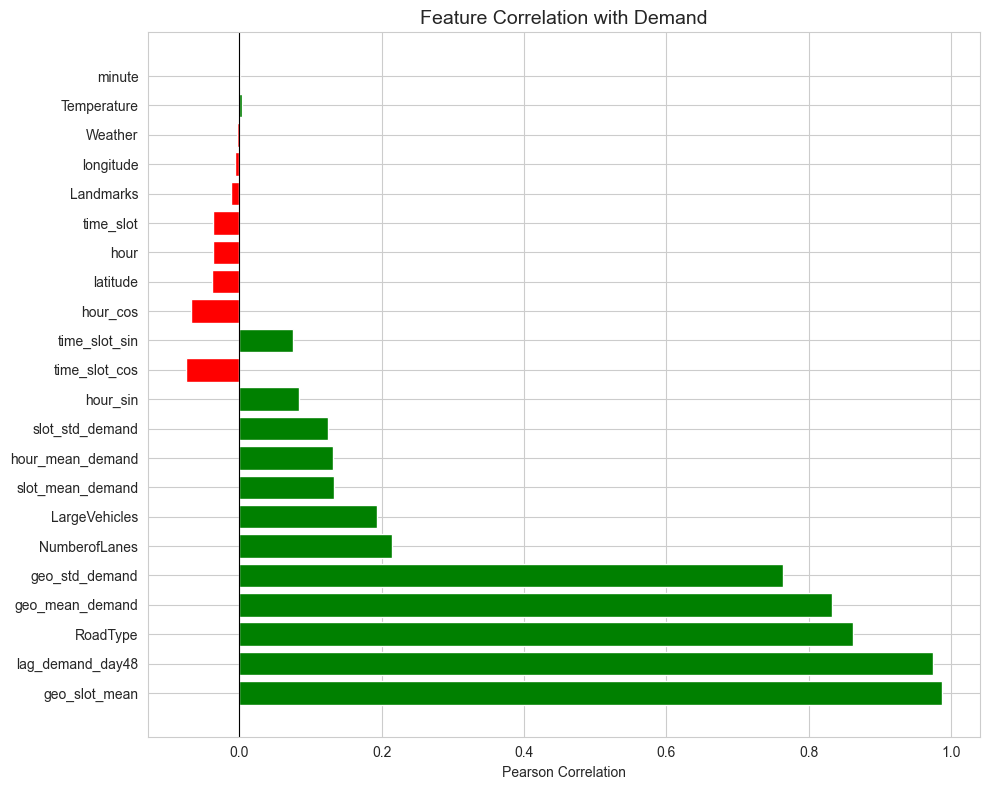


=== TOP FEATURES BY CORRELATION ===
geo_slot_mean       0.987599
lag_demand_day48    0.974900
RoadType            0.862572
geo_mean_demand     0.833264
geo_std_demand      0.763928
NumberofLanes       0.214148
LargeVehicles       0.193623
slot_mean_demand    0.133403
hour_mean_demand    0.131216
slot_std_demand     0.124757
Name: demand, dtype: float64


In [80]:
# See which features correlate most with demand
# Higher absolute correlation = more useful feature

corr = X_train.copy()
corr['demand'] = y_train

correlation_with_target = corr.corr()['demand'].drop('demand').sort_values(
    key=abs, ascending=False
)

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in correlation_with_target.values]
plt.barh(correlation_with_target.index, correlation_with_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Demand', fontsize=14)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("\n=== TOP FEATURES BY CORRELATION ===")
print(correlation_with_target.head(10))

In [ ]:
###--------##### we will build a model before a complex model


### our baseline in order of complexity 
 # predict meand demand for everyone ------> worstt
 # predict mean demand per geohash-------->
 # predict lag_demand_day48

##import libraries



from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
import lightgbm as lgb
import xgboost as xgb
import time



##helperr function that we will reuse everywhere that calculates the competition matrix

def competition_score(y_true, y_pred):
    """Calculates the exact hackathon scoring formula"""
    score = max(0, 100 * r2_score(y_true, y_pred))
    return round(score, 4)

In [ ]:
import sys
!{sys.executable} -m pip install lightgbm

import sys
!{sys.executable} -m pip install xgboost